In [1]:
import os
from typing import Optional

from matplotlib import cm
from matplotlib import patches
from matplotlib import pyplot as plt
from matplotlib import ticker
import numpy as np


In [2]:
def plot_2d_map(coord_x: np.ndarray,
                coord_y: np.ndarray,
                values: np.ndarray,
                holes_info: Optional[np.ndarray] = None) -> None:
    """Plots a 2D map for a plate with or without holes.

    Args:
        coord_x: A 1-dimensional numpy array containing the x-coordinates of all 
          points on the 2D mesh.
        coord_y: A 1-dimensional numpy array containing the y-coordinates of all 
          points on the 2D mesh.
        values: A 1-dimensional numpy array containing the values to be plotted 
          for all points on the 2D mesh.
        holes_info: A 2-dimensional numpy array containing the information of 
          the centers and radius of the holes. Each row should have 3 values: 
          x-coordinate of the center of the hole, y-coordinate of the center of
          the hole, and the radius of the hole. Default is None if the plate has 
          no holes.
    """

    # Create a figure and axes object
    _, axes = plt.subplots(figsize=(6, 10))

    # Choose the number of levels and color map
    levels = ticker.MaxNLocator(nbins=800).tick_values(values.min(),
                                                       values.max())
    cmap = cm.get_cmap(name="jet", lut=None)

    # Add the stress map to the plot
    contour_set = axes.tricontourf(coord_x,
                                   coord_y,
                                   values,
                                   levels=levels,
                                   cmap=cmap)

    # Add holes to the plot
    if holes_info is not None:
        for hole_info in holes_info:
            circle = patches.Ellipse((hole_info[0], hole_info[1]),
                                    hole_info[2]*2,hole_info[3]*2, angle=hole_info[4],
                                    facecolor="white")
            axes.add_patch(circle)

    # Add color bar to the plot
    plt.colorbar(contour_set)

    # Set the limits of the axes
    x_min, x_max = np.min(coord_x), np.max(coord_x)
    y_min, y_max = np.min(coord_y), np.max(coord_y)
    axes.set_xlim(x_min, x_max)
    axes.set_ylim(y_min, y_max)

    # Remove the axes
    plt.axis("off")

    # Show the plot
    plt.show()

In [3]:
id=6

In [4]:
h_y=np.load("./data_geometry//"+str(id)+"//H_y.npy")
h_pos=np.load("./data_geometry//"+str(id)+"//H_mesh_geometry.npy")
h_holes=np.load("./data_geometry//"+str(id)+"//H_holes.npy")
h_topology=np.load("./data_geometry//"+str(id)+"//H_mesh_topology.npy")

l_y=np.load("./data_geometry//"+str(id)+"//L_y.npy")
l_pos=np.load("./data_geometry//"+str(id)+"//L_mesh_geometry.npy")
l_holes=np.load("./data_geometry//"+str(id)+"//L_holes.npy")
l_topology=np.load("./data_geometry//"+str(id)+"//L_mesh_topology.npy")

/tmp/ipykernel_26114/3323061255.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(name="jet", lut=None)


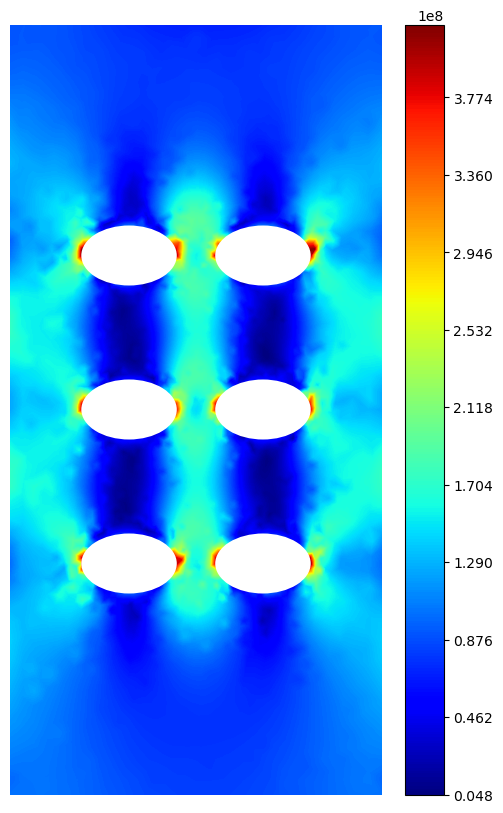

In [5]:
plot_2d_map(h_pos[:,0],h_pos[:,1],h_y.reshape(-1),h_holes)

/tmp/ipykernel_26114/3323061255.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(name="jet", lut=None)


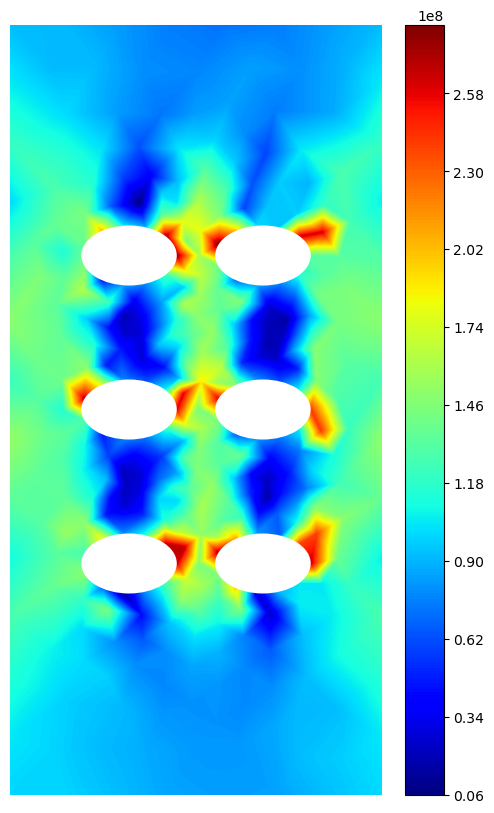

In [6]:
plot_2d_map(l_pos[:,0],l_pos[:,1],l_y.reshape(-1),l_holes)